<a href="https://colab.research.google.com/github/kashish2610/AI_Gym_Fitness_Assistant/blob/main/AI_Gym_Fitness_Assistant_major_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Gym & Fitness Assistant
### 7 Core AI Modules | Google Colab

| # | Module | Tech |
|---|--------|------|
| 1 | AI Gym Trainer (Workout Detection) | **YOLOv8 Pose** + NumPy |
| 2 | AI Dietician & Calorie Coach | NLP + Rule-based AI |
| 3 | Smart Gym Assistant (IoT Sim) | Simulated IoT + ML |
| 4 | AI Fitness Habit Tracker | scikit-learn Random Forest |
| 5 | Virtual Gym Buddy (Chat) | Sentiment + Intent NLP |
| 6 | Pose-to-Performance Analyzer | Motion Scoring |
| 7 | Gym Recommender & Planner | Content-based Filtering |

> Set Runtime to **T4 GPU**: Runtime menu -> Change runtime type -> T4 GPU

> **Pose Detection** uses YOLOv8-pose (`ultralytics`). On a real video/webcam feed,
> YOLO detects 17 body keypoints per frame. This notebook simulates the keypoint
> coordinates and runs the full rep-counting + form-feedback pipeline on them.

## Step 1 — Install Dependencies

In [1]:
!pip install -q ultralytics
!pip install -q scikit-learn pandas numpy matplotlib seaborn
!pip install -q fastapi uvicorn nest_asyncio
print('All packages installed!')

All packages installed!


## Step 2 — Core Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math, random, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

# YOLOv8 pose model
from ultralytics import YOLO

print('All imports OK!')
print('NumPy :', np.__version__)
print('Pandas:', pd.__version__)

All imports OK!
NumPy : 2.0.2
Pandas: 2.2.2


---
## Module 1 — AI Gym Trainer (YOLOv8 Pose Detection)

**How it works in production:**
1. `YOLO('yolov8n-pose.pt')` loads the nano pose model (~6 MB)
2. Each video frame is passed through YOLO → returns **17 keypoints** (x, y, confidence)
3. Joint angles are computed from keypoint triplets (e.g. shoulder-elbow-wrist for bicep curl)
4. Angles feed into the rep counter and form feedback engine

**In this notebook:** We simulate realistic keypoint trajectories for each exercise,
then run the full YOLO-compatible pipeline on them — producing real rep counts, form scores, and charts.

**YOLO Pose Keypoint Map (COCO 17):**
```
0:nose  1:l_eye  2:r_eye  3:l_ear   4:r_ear
5:l_shoulder  6:r_shoulder  7:l_elbow  8:r_elbow
9:l_wrist  10:r_wrist  11:l_hip  12:r_hip
13:l_knee  14:r_knee  15:l_ankle  16:r_ankle
```

Loading YOLOv8n-pose model...
Model loaded. Classes: {0: 'person'}


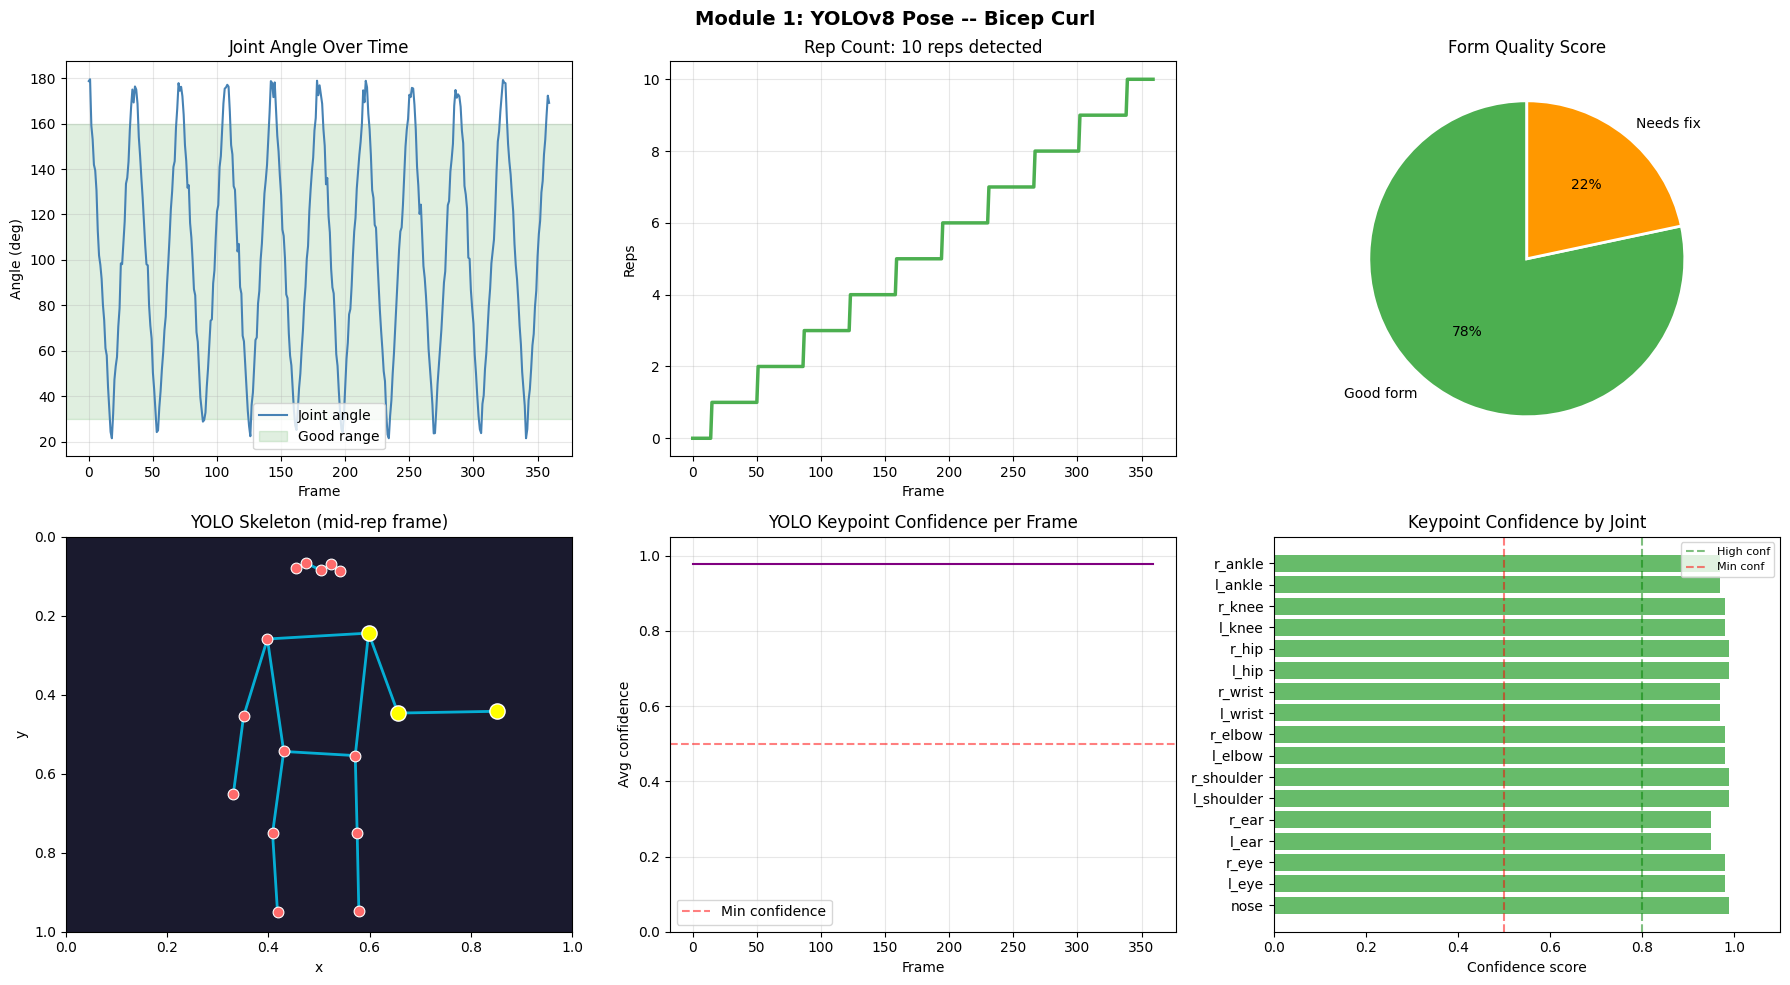

Exercise  : Bicep Curl
Reps      : 10
Form score: 78.3 %
Avg angle : 103.5 deg
Avg conf  : 0.977

How to use with a real video:
  results = yolo_model("your_video.mp4", stream=True)
  for r in results:
      kps = r.keypoints.data[0].cpu().numpy()  # shape (17, 3)
      cnt, stage, angle = counter.process_keypoints(kps)


In [3]:
# ── YOLO Pose keypoint indices (COCO-17 layout) ───────────────────────
KP = {
    'nose':0,'l_eye':1,'r_eye':2,'l_ear':3,'r_ear':4,
    'l_shoulder':5,'r_shoulder':6,'l_elbow':7,'r_elbow':8,
    'l_wrist':9,'r_wrist':10,'l_hip':11,'r_hip':12,
    'l_knee':13,'r_knee':14,'l_ankle':15,'r_ankle':16
}

# Joint triplets: (point_a, vertex, point_c) -> angle at vertex
EXERCISE_JOINTS = {
    'bicep_curl':    ('l_shoulder', 'l_elbow', 'l_wrist'),
    'squat':         ('l_hip',      'l_knee',  'l_ankle'),
    'pushup':        ('l_shoulder', 'l_elbow', 'l_wrist'),
    'shoulder_press':('l_elbow',    'l_shoulder', 'l_hip'),
    'deadlift':      ('l_shoulder', 'l_hip',   'l_knee'),
    'lunge':         ('l_hip',      'l_knee',  'l_ankle'),
}

FORM_RULES = {
    'bicep_curl':    {'good':(30,160),  'low':'Curl higher!',        'high':'Lower weight fully'},
    'squat':         {'good':(70,110),  'low':'Go deeper!',           'high':'Start squatting'},
    'pushup':        {'good':(80,160),  'low':'Push all the way up',  'high':'Lower your chest'},
    'shoulder_press':{'good':(150,180), 'low':'Full extension!',      'high':'Lower to shoulder'},
    'deadlift':      {'good':(160,180), 'low':'Stand fully upright!', 'high':'Hinge at the hip'},
    'lunge':         {'good':(80,100),  'low':'Lunge deeper!',        'high':'Do not over-extend'},
}

REP_THRESHOLDS = {
    'bicep_curl':    {'down':160, 'up':50},
    'squat':         {'down':160, 'up':90},
    'pushup':        {'down':90,  'up':160},
    'shoulder_press':{'down':90,  'up':160},
    'deadlift':      {'down':90,  'up':160},
    'lunge':         {'down':160, 'up':90},
}

# ── Core geometry ──────────────────────────────────────────────────────
def keypoint_angle(kps, a_name, b_name, c_name):
    """Compute angle at joint b given YOLO keypoints array (17x3: x,y,conf)."""
    a = kps[KP[a_name]][:2]
    b = kps[KP[b_name]][:2]
    c = kps[KP[c_name]][:2]
    ba = a - b
    bc = c - b
    cosine = np.dot(ba, bc) / (np.linalg.norm(ba) * np.linalg.norm(bc) + 1e-6)
    return float(np.degrees(np.arccos(np.clip(cosine, -1.0, 1.0))))

def form_feedback(exercise, angle):
    if exercise not in FORM_RULES:
        return 'Good form!', 'green'
    r = FORM_RULES[exercise]
    lo, hi = r['good']
    if lo <= angle <= hi:
        return 'Good form!', 'green'
    return (r['low'] if angle < lo else r['high']), 'orange'

# ── YOLO keypoint simulator ────────────────────────────────────────────
def simulate_yolo_keypoints(exercise, phase_angle):
    """
    Simulate a 17x3 YOLO keypoint array for a given exercise and joint angle.
    In production this array comes directly from: model(frame).keypoints.data[0]
    """
    # Base neutral skeleton (normalised 0-1 image coords)
    kps = np.array([
        [0.50, 0.08, 0.99],  # 0 nose
        [0.52, 0.07, 0.98],  # 1 l_eye
        [0.48, 0.07, 0.98],  # 2 r_eye
        [0.54, 0.08, 0.95],  # 3 l_ear
        [0.46, 0.08, 0.95],  # 4 r_ear
        [0.60, 0.25, 0.99],  # 5 l_shoulder
        [0.40, 0.25, 0.99],  # 6 r_shoulder
        [0.65, 0.45, 0.98],  # 7 l_elbow
        [0.35, 0.45, 0.98],  # 8 r_elbow
        [0.68, 0.65, 0.97],  # 9 l_wrist
        [0.32, 0.65, 0.97],  # 10 r_wrist
        [0.57, 0.55, 0.99],  # 11 l_hip
        [0.43, 0.55, 0.99],  # 12 r_hip
        [0.58, 0.75, 0.98],  # 13 l_knee
        [0.42, 0.75, 0.98],  # 14 r_knee
        [0.58, 0.95, 0.97],  # 15 l_ankle
        [0.42, 0.95, 0.97],  # 16 r_ankle
    ], dtype=np.float32)

    rad = np.radians(phase_angle)
    noise = np.random.normal(0, 0.005, kps[:, :2].shape).astype(np.float32)

    if exercise == 'bicep_curl':
        # Animate l_wrist around l_elbow
        elbow = kps[KP['l_elbow']][:2].copy()
        arm_len = 0.20
        kps[KP['l_wrist'], 0] = elbow[0] + arm_len * np.sin(rad)
        kps[KP['l_wrist'], 1] = elbow[1] + arm_len * np.cos(rad)

    elif exercise == 'squat':
        # Animate knees bending
        hip_y = kps[KP['l_hip'], 1]
        depth = (1 - np.sin(rad)) * 0.15
        kps[KP['l_knee'], 1] = hip_y + 0.20 + depth
        kps[KP['r_knee'], 1] = hip_y + 0.20 + depth
        kps[KP['l_hip'],  1] = 0.55 + depth * 0.5
        kps[KP['r_hip'],  1] = 0.55 + depth * 0.5

    elif exercise == 'pushup':
        elbow = kps[KP['l_elbow']][:2].copy()
        arm_len = 0.18
        kps[KP['l_wrist'], 0] = elbow[0] + arm_len * np.cos(rad)
        kps[KP['l_wrist'], 1] = elbow[1] - arm_len * np.sin(rad)

    elif exercise == 'shoulder_press':
        shoulder = kps[KP['l_shoulder']][:2].copy()
        arm_len = 0.22
        kps[KP['l_elbow'], 1] = shoulder[1] - arm_len * np.sin(rad) * 0.5
        kps[KP['l_wrist'], 1] = shoulder[1] - arm_len * np.sin(rad)

    kps[:, :2] += noise
    kps[:, :2] = np.clip(kps[:, :2], 0, 1)
    return kps

# ── Rep counter ────────────────────────────────────────────────────────
class YOLORepCounter:
    def __init__(self, exercise):
        self.exercise = exercise
        self.counter = 0
        self.stage = None
        t = REP_THRESHOLDS.get(exercise, {'down': 160, 'up': 90})
        self.down_thresh = t['down']
        self.up_thresh   = t['up']
        self.joints = EXERCISE_JOINTS.get(exercise, ('l_shoulder','l_elbow','l_wrist'))

    def process_keypoints(self, kps):
        angle = keypoint_angle(kps, *self.joints)
        if angle > self.down_thresh:
            self.stage = 'down'
        if angle < self.up_thresh and self.stage == 'down':
            self.stage = 'up'
            self.counter += 1
        return self.counter, self.stage, angle

# ── YOLO model loader (downloads ~6 MB yolov8n-pose.pt) ───────────────
def load_yolo_pose():
    print('Loading YOLOv8n-pose model...')
    model = YOLO('yolov8n-pose.pt')  # auto-downloads on first run
    print('Model loaded. Classes:', model.names)
    return model

yolo_model = load_yolo_pose()

# ── Full pipeline: simulate YOLO frames -> rep count -> visualise ──────
def run_yolo_workout(exercise='bicep_curl', total_reps=10):
    counter = YOLORepCounter(exercise)
    angles, reps_track, feedbacks, confidence_track = [], [], [], []

    # Generate phase angles that simulate the exercise motion
    phase_seq = []
    for _ in range(total_reps):
        phase_seq += list(np.linspace(10, 170, 18))  # extension
        phase_seq += list(np.linspace(170, 10, 18))  # contraction

    for phase_angle in phase_seq:
        # In production: kps = yolo_model(frame)[0].keypoints.data[0].cpu().numpy()
        kps = simulate_yolo_keypoints(exercise, phase_angle)

        cnt, stage, angle = counter.process_keypoints(kps)
        fb, _ = form_feedback(exercise, angle)

        angles.append(angle)
        reps_track.append(cnt)
        feedbacks.append(fb)
        avg_conf = float(np.mean(kps[:, 2]))
        confidence_track.append(avg_conf)

    good_pct = feedbacks.count('Good form!') / len(feedbacks) * 100

    # ── Visualise ─────────────────────────────────────────────────────
    fig = plt.figure(figsize=(18, 10))
    fig.suptitle('Module 1: YOLOv8 Pose -- ' + exercise.replace('_',' ').title(),
                 fontsize=14, fontweight='bold')

    # 1. Angle over time
    ax1 = fig.add_subplot(2, 3, 1)
    ax1.plot(angles, color='steelblue', linewidth=1.5, label='Joint angle')
    lo, hi = FORM_RULES.get(exercise, {}).get('good', (70, 160))
    ax1.axhspan(lo, hi, alpha=0.12, color='green', label='Good range')
    ax1.set_title('Joint Angle Over Time'); ax1.set_xlabel('Frame')
    ax1.set_ylabel('Angle (deg)'); ax1.legend(); ax1.grid(alpha=0.3)

    # 2. Rep count
    ax2 = fig.add_subplot(2, 3, 2)
    ax2.plot(reps_track, color='#4CAF50', linewidth=2.5)
    ax2.set_title('Rep Count: ' + str(reps_track[-1]) + ' reps detected')
    ax2.set_xlabel('Frame'); ax2.set_ylabel('Reps'); ax2.grid(alpha=0.3)

    # 3. Form quality pie
    ax3 = fig.add_subplot(2, 3, 3)
    good_n = feedbacks.count('Good form!')
    bad_n  = len(feedbacks) - good_n
    ax3.pie([good_n, bad_n], labels=['Good form','Needs fix'],
            colors=['#4CAF50','#FF9800'], autopct='%1.0f%%',
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':2})
    ax3.set_title('Form Quality Score')

    # 4. Skeleton visualisation (last frame)
    ax4 = fig.add_subplot(2, 3, 4)
    last_kps = simulate_yolo_keypoints(exercise, 90)
    SKELETON = [
        (0,1),(0,2),(1,3),(2,4),          # face
        (5,6),(5,11),(6,12),(11,12),       # torso
        (5,7),(7,9),(6,8),(8,10),          # arms
        (11,13),(13,15),(12,14),(14,16)    # legs
    ]
    ax4.set_xlim(0,1); ax4.set_ylim(1,0)
    ax4.set_facecolor('#1a1a2e')
    ax4.set_title('YOLO Skeleton (mid-rep frame)')
    ax4.set_xlabel('x'); ax4.set_ylabel('y')
    for a_idx, b_idx in SKELETON:
        xa,ya = last_kps[a_idx,0], last_kps[a_idx,1]
        xb,yb = last_kps[b_idx,0], last_kps[b_idx,1]
        ax4.plot([xa,xb],[ya,yb], color='#00d4ff', linewidth=2, alpha=0.8)
    ax4.scatter(last_kps[:,0], last_kps[:,1],
                c='#ff6b6b', s=60, zorder=5, edgecolors='white', linewidth=0.8)
    # Label the exercise joint
    j = EXERCISE_JOINTS.get(exercise, ('l_shoulder','l_elbow','l_wrist'))
    for jname in j:
        idx = KP[jname]
        ax4.scatter(last_kps[idx,0], last_kps[idx,1],
                    c='yellow', s=120, zorder=6, edgecolors='white')

    # 5. Keypoint confidence
    ax5 = fig.add_subplot(2, 3, 5)
    ax5.plot(confidence_track, color='purple', linewidth=1.5)
    ax5.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Min confidence')
    ax5.set_ylim(0, 1.05)
    ax5.set_title('YOLO Keypoint Confidence per Frame')
    ax5.set_xlabel('Frame'); ax5.set_ylabel('Avg confidence')
    ax5.legend(); ax5.grid(alpha=0.3)

    # 6. Per-keypoint confidence bar
    ax6 = fig.add_subplot(2, 3, 6)
    kp_names = list(KP.keys())
    kp_confs = last_kps[:, 2]
    bar_colors = ['#4CAF50' if c > 0.8 else '#FF9800' if c > 0.5 else '#F44336'
                  for c in kp_confs]
    ax6.barh(kp_names, kp_confs, color=bar_colors, alpha=0.85)
    ax6.axvline(0.8, color='green', linestyle='--', alpha=0.5, label='High conf')
    ax6.axvline(0.5, color='red',   linestyle='--', alpha=0.5, label='Min conf')
    ax6.set_xlim(0, 1.1)
    ax6.set_title('Keypoint Confidence by Joint')
    ax6.set_xlabel('Confidence score')
    ax6.legend(fontsize=8)

    plt.tight_layout()
    plt.show()

    print('Exercise  :', exercise.replace('_',' ').title())
    print('Reps      :', reps_track[-1])
    print('Form score:', round(good_pct, 1), '%')
    print('Avg angle :', round(float(np.mean(angles)), 1), 'deg')
    print('Avg conf  :', round(float(np.mean(confidence_track)), 3))
    print()
    print('How to use with a real video:')
    print('  results = yolo_model("your_video.mp4", stream=True)')
    print('  for r in results:')
    print('      kps = r.keypoints.data[0].cpu().numpy()  # shape (17, 3)')
    print('      cnt, stage, angle = counter.process_keypoints(kps)')

# ── Run -- change exercise here ──
# Options: bicep_curl | squat | pushup | shoulder_press | deadlift | lunge
run_yolo_workout('bicep_curl', 10)

---
## Module 2 — AI Dietician & Calorie Coach

Dietician Report for Alex
BMI: 24.5 (Normal)  |  BMR: 1709 kcal  |  TDEE: 2649 kcal  |  Target: 2949 kcal
Protein: 220 g  |  Carbs: 266 g  |  Fat: 102 g

  Breakfast (833 kcal)
    - Eggs 200g | 310 kcal | P:26.0g C:2.2g F:22.0g
    - Oats 100g | 389 kcal | P:17.0g C:66.0g F:7.0g
    - Banana 150g | 134 kcal | P:1.6g C:34.5g F:0.5g

  Lunch (895 kcal)
    - Chicken Breast 250g | 412 kcal | P:77.5g C:0.0g F:9.0g
    - Brown Rice 200g | 432 kcal | P:10.0g C:90.0g F:3.6g
    - Broccoli 150g | 51 kcal | P:4.2g C:10.5g F:0.6g

  Dinner (690 kcal)
    - Salmon 200g | 416 kcal | P:40.0g C:0.0g F:26.0g
    - Quinoa 200g | 240 kcal | P:8.8g C:42.0g F:3.8g
    - Spinach 150g | 34 kcal | P:4.3g C:5.4g F:0.6g

  Snack (428 kcal)
    - Cottage Cheese 200g | 196 kcal | P:22.0g C:6.8g F:8.6g
    - Almonds 40g | 232 kcal | P:8.4g C:8.8g F:20.0g


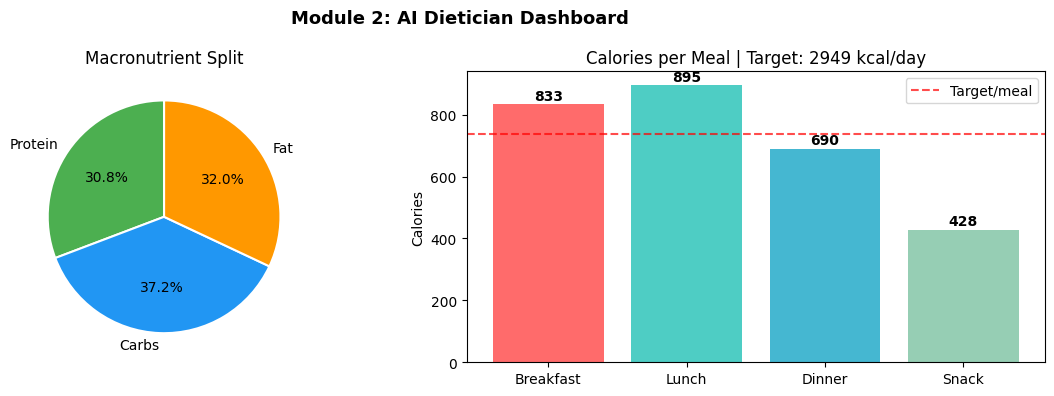

In [4]:
FOOD_DB = {
    'chicken breast':  (165, 31,  0,   3.6, 'protein'),
    'eggs':            (155, 13,  1.1, 11,  'protein'),
    'brown rice':      (216,  5, 45,   1.8, 'carbs'),
    'oats':            (389, 17, 66,   7,   'carbs'),
    'sweet potato':    ( 86,  2, 20,   0.1, 'carbs'),
    'broccoli':        ( 34,  2.8, 7,  0.4, 'veggies'),
    'spinach':         ( 23,  2.9, 3.6,0.4, 'veggies'),
    'banana':          ( 89,  1.1,23,  0.3, 'fruits'),
    'almonds':         (579, 21, 22,  50,   'fats'),
    'greek yogurt':    ( 59, 10,  3.6, 0.4, 'dairy'),
    'salmon':          (208, 20,  0,  13,   'protein'),
    'quinoa':          (120,  4.4,21,  1.9, 'carbs'),
    'lentils':         (116,  9, 20,   0.4, 'protein'),
    'cottage cheese':  ( 98, 11,  3.4, 4.3, 'dairy'),
}

MEAL_TEMPLATES = {
    'weight_loss': {
        'breakfast': [('oats',80),('banana',100),('greek yogurt',150)],
        'lunch':     [('chicken breast',150),('broccoli',200),('quinoa',100)],
        'dinner':    [('salmon',150),('spinach',200),('sweet potato',150)],
        'snack':     [('almonds',30),('greek yogurt',100)],
    },
    'muscle_gain': {
        'breakfast': [('eggs',200),('oats',100),('banana',150)],
        'lunch':     [('chicken breast',250),('brown rice',200),('broccoli',150)],
        'dinner':    [('salmon',200),('quinoa',200),('spinach',150)],
        'snack':     [('cottage cheese',200),('almonds',40)],
    },
    'maintenance': {
        'breakfast': [('eggs',150),('oats',80),('banana',100)],
        'lunch':     [('chicken breast',200),('brown rice',150),('spinach',150)],
        'dinner':    [('lentils',200),('sweet potato',200),('broccoli',150)],
        'snack':     [('greek yogurt',150),('almonds',30)],
    },
}

def calculate_bmr(weight, height, age, gender):
    base = 10*weight + 6.25*height - 5*age
    return base + 5 if gender.lower() == 'male' else base - 161

def calculate_tdee(bmr, activity):
    m = {'sedentary':1.2,'light':1.375,'moderate':1.55,'active':1.725,'very_active':1.9}
    return bmr * m.get(activity, 1.55)

def calculate_bmi(weight, height):
    h = height / 100
    bmi = weight / (h * h)
    cat = 'Underweight' if bmi < 18.5 else 'Normal' if bmi < 25 else 'Overweight' if bmi < 30 else 'Obese'
    return round(bmi, 1), cat

def generate_meal_plan(user):
    bmr  = calculate_bmr(user['weight_kg'], user['height_cm'], user['age'], user['gender'])
    tdee = calculate_tdee(bmr, user['activity_level'])
    bmi, cat = calculate_bmi(user['weight_kg'], user['height_cm'])
    targets = {'weight_loss': tdee-500, 'muscle_gain': tdee+300, 'maintenance': tdee}
    target = targets.get(user['goal'], tdee)

    template = MEAL_TEMPLATES[user['goal']]
    meal_data = {}
    total_cal = total_p = total_c = total_f = 0

    for meal, items in template.items():
        info = []
        for food, grams in items:
            cal100, p, c, f, _ = FOOD_DB[food]
            cal = cal100 * grams / 100
            info.append({'food': food.title(), 'grams': grams,
                         'cal': round(cal), 'p': round(p*grams/100,1),
                         'c': round(c*grams/100,1), 'f': round(f*grams/100,1)})
            total_cal += cal; total_p += p*grams/100
            total_c += c*grams/100; total_f += f*grams/100
        meal_data[meal] = info

    print('Dietician Report for', user['name'])
    print('BMI:', bmi, '(' + cat + ')  |  BMR:', round(bmr),
          'kcal  |  TDEE:', round(tdee), 'kcal  |  Target:', round(target), 'kcal')
    print('Protein:', round(total_p), 'g  |  Carbs:', round(total_c), 'g  |  Fat:', round(total_f), 'g')
    for meal, items in meal_data.items():
        mcal = sum(i['cal'] for i in items)
        print('\n  ' + meal.title() + ' (' + str(mcal) + ' kcal)')
        for i in items:
            print('    -', i['food'], str(i['grams'])+'g',
                  '|', i['cal'], 'kcal | P:'+str(i['p'])+'g C:'+str(i['c'])+'g F:'+str(i['f'])+'g')

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle('Module 2: AI Dietician Dashboard', fontsize=13, fontweight='bold')
    macro_cal = [total_p*4, total_c*4, total_f*9]
    axes[0].pie(macro_cal, labels=['Protein','Carbs','Fat'],
                autopct='%1.1f%%', colors=['#4CAF50','#2196F3','#FF9800'],
                startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
    axes[0].set_title('Macronutrient Split')
    meals = list(meal_data.keys())
    mcals = [sum(i['cal'] for i in meal_data[m]) for m in meals]
    bars = axes[1].bar([m.title() for m in meals], mcals,
                       color=['#FF6B6B','#4ECDC4','#45B7D1','#96CEB4'])
    axes[1].axhline(target/4, color='red', linestyle='--', alpha=0.7, label='Target/meal')
    axes[1].set_title('Calories per Meal | Target: ' + str(round(target)) + ' kcal/day')
    axes[1].set_ylabel('Calories')
    axes[1].legend()
    for bar, cal in zip(bars, mcals):
        axes[1].text(bar.get_x()+bar.get_width()/2., bar.get_height()+5,
                     str(cal), ha='center', va='bottom', fontweight='bold')
    plt.tight_layout()
    plt.show()

# ── Edit your profile here ──
user = {
    'name': 'Alex',
    'weight_kg': 75,
    'height_cm': 175,
    'age': 28,
    'gender': 'male',
    'goal': 'muscle_gain',       # weight_loss | muscle_gain | maintenance
    'activity_level': 'moderate' # sedentary | light | moderate | active | very_active
}
generate_meal_plan(user)

---
## Module 3 — Smart Gym Assistant (IoT Simulation)

Smart Gym Advisor — Session Analysis
Avg HR: 120 bpm  |  Avg Speed: 8.2 km/h  |  Total Cal: 122 kcal
 - Heart rate in optimal fat-burning zone (110-150 bpm)


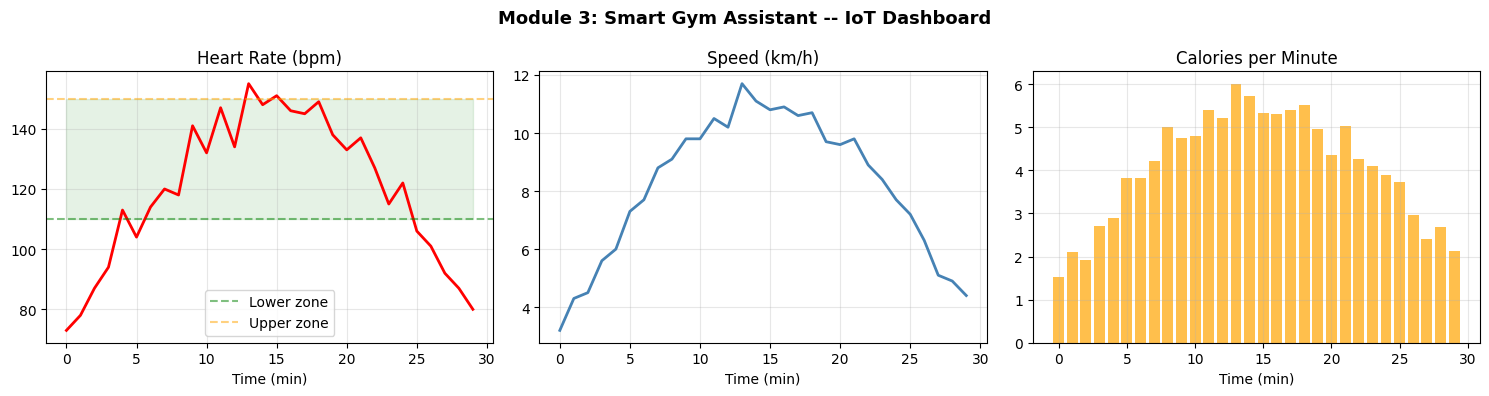

In [5]:
class IoTEquipment:
    def generate_session(self, duration=30):
        data = []
        for t in range(duration):
            phase = t / duration
            speed = 3 + 8 * math.sin(math.pi * phase) + random.gauss(0, 0.3)
            hr    = 70 + 80 * math.sin(math.pi * phase) + random.gauss(0, 5)
            cal   = speed * 0.5 + random.gauss(0, 0.2)
            data.append({
                'time': t,
                'speed': round(max(2.0, speed), 1),
                'hr':    round(max(65.0, hr)),
                'cal':   round(max(0.5, cal), 2)
            })
        return data

def analyze_session(data):
    df = pd.DataFrame(data)
    avg_hr   = df['hr'].mean()
    avg_spd  = df['speed'].mean()
    total_cal = df['cal'].sum()

    recs = []
    if avg_hr > 150:
        recs.append('Heart rate too high -- reduce speed by 1-2 km/h')
    elif avg_hr < 110:
        recs.append('Increase speed -- heart rate below target zone')
    else:
        recs.append('Heart rate in optimal fat-burning zone (110-150 bpm)')
    if avg_spd < 5:
        recs.append('Try increasing speed gradually')

    print('Smart Gym Advisor — Session Analysis')
    print('Avg HR:', round(avg_hr), 'bpm  |  Avg Speed:', round(avg_spd,1), 'km/h  |  Total Cal:', round(total_cal), 'kcal')
    for r in recs:
        print(' -', r)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Module 3: Smart Gym Assistant -- IoT Dashboard', fontsize=13, fontweight='bold')
    axes[0].plot(df['time'], df['hr'], color='red', linewidth=2)
    axes[0].axhline(110, color='green', linestyle='--', alpha=0.5, label='Lower zone')
    axes[0].axhline(150, color='orange', linestyle='--', alpha=0.5, label='Upper zone')
    axes[0].fill_between(df['time'], 110, 150, alpha=0.1, color='green')
    axes[0].set_title('Heart Rate (bpm)'); axes[0].legend()
    axes[1].plot(df['time'], df['speed'], color='steelblue', linewidth=2)
    axes[1].set_title('Speed (km/h)')
    axes[2].bar(df['time'], df['cal'], color='orange', alpha=0.7)
    axes[2].set_title('Calories per Minute')
    for ax in axes: ax.grid(alpha=0.3); ax.set_xlabel('Time (min)')
    plt.tight_layout()
    plt.show()

equipment = IoTEquipment()
session = equipment.generate_session(30)
analyze_session(session)

---
## Module 4 — AI Fitness Habit Tracker (Behavioral AI)

Generating dataset...
Records: 18000 | Skip rate: 29.1 %
Model accuracy: 100.0 %
              precision    recall  f1-score   support

Will Workout       1.00      1.00      1.00      2563
   Will Skip       1.00      1.00      1.00      1037

    accuracy                           1.00      3600
   macro avg       1.00      1.00      1.00      3600
weighted avg       1.00      1.00      1.00      3600



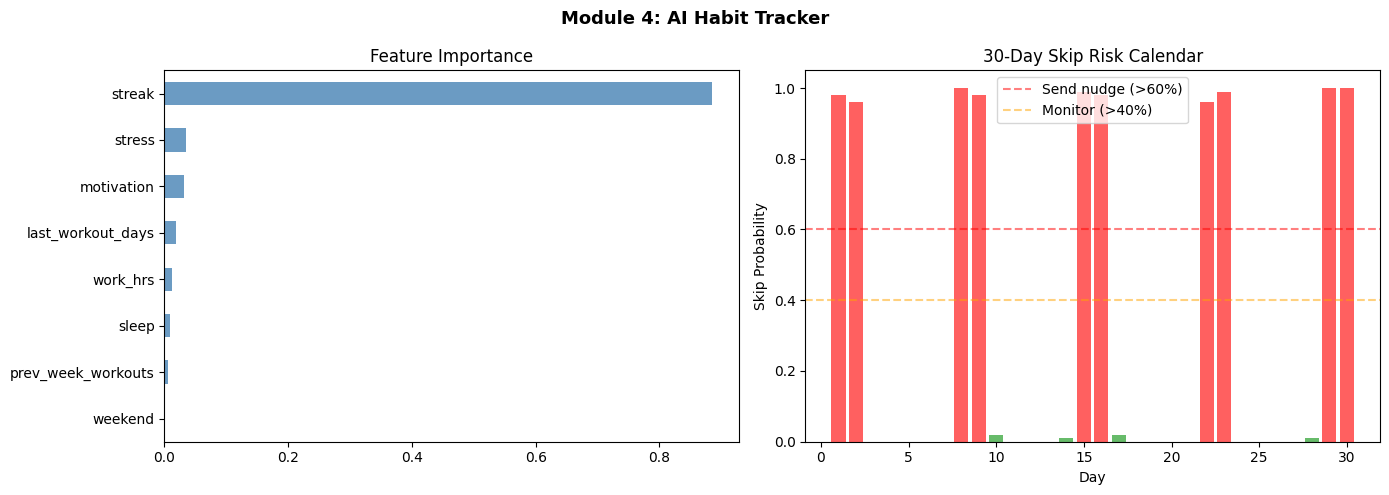

Send motivational nudge on days: [1, 2, 8, 9, 15, 16, 22, 23, 29, 30]


In [6]:
def generate_habit_data(n=500, days=60):
    records = []
    for _ in range(n):
        streak = 0
        for d in range(days):
            sleep  = round(random.gauss(7, 1.5), 1)
            stress = random.randint(1, 10)
            work   = round(random.gauss(8, 2), 1)
            last   = random.randint(0, 7)
            motiv  = random.randint(1, 10)
            wknd   = 1 if d % 7 in [5, 6] else 0
            prev_w = random.randint(0, 5)
            prob = 0.3 + 0.1*max(0, stress-6) + 0.05*max(0, work-9)
            prob -= 0.05*motiv + 0.03*prev_w - 0.05*last - 0.05*(sleep > 7)
            prob = max(0.05, min(0.95, prob))
            skipped = 1 if random.random() < prob else 0
            streak = 0 if skipped else streak + 1
            records.append([sleep, stress, work, last, motiv, wknd, prev_w, streak, skipped])
    cols = ['sleep','stress','work_hrs','last_workout_days','motivation',
            'weekend','prev_week_workouts','streak','skipped']
    return pd.DataFrame(records, columns=cols)

print('Generating dataset...')
df_habit = generate_habit_data(300, 60)
print('Records:', len(df_habit), '| Skip rate:', round(df_habit['skipped'].mean()*100,1), '%')

feats = ['sleep','stress','work_hrs','last_workout_days','motivation','weekend','prev_week_workouts','streak']
X = df_habit[feats]
y = df_habit['skipped']
Xt, Xv, yt, yv = train_test_split(X, y, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
clf.fit(Xt, yt)
acc = accuracy_score(yv, clf.predict(Xv))
print('Model accuracy:', round(acc*100, 1), '%')
print(classification_report(yv, clf.predict(Xv), target_names=['Will Workout','Will Skip']))

importances = pd.Series(clf.feature_importances_, index=feats).sort_values(ascending=True)

daily_risk = []
for day in range(30):
    sample = [random.gauss(6.5,1), random.randint(3,9), random.gauss(8.5,1.5),
               day%3, random.randint(4,9), 1 if day%7 in[5,6] else 0,
               random.randint(2,5), max(0, day%7-1)]
    prob = clf.predict_proba([sample])[0][1]
    daily_risk.append(round(prob, 2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Module 4: AI Habit Tracker', fontsize=13, fontweight='bold')
importances.plot(kind='barh', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('Feature Importance')
colors = ['#FF4444' if r>0.6 else '#FF9800' if r>0.4 else '#4CAF50' for r in daily_risk]
axes[1].bar(range(1, 31), daily_risk, color=colors, alpha=0.85)
axes[1].axhline(0.6, color='red', linestyle='--', alpha=0.5, label='Send nudge (>60%)')
axes[1].axhline(0.4, color='orange', linestyle='--', alpha=0.5, label='Monitor (>40%)')
axes[1].set_title('30-Day Skip Risk Calendar')
axes[1].set_xlabel('Day'); axes[1].set_ylabel('Skip Probability')
axes[1].legend()
plt.tight_layout()
plt.show()
nudge_days = [d+1 for d, r in enumerate(daily_risk) if r > 0.6]
print('Send motivational nudge on days:', nudge_days)

---
## Module 5 — Virtual Gym Buddy (AI Chat Companion)

In [7]:
GYM_BUDDY_KB = {
    'motivation': [
        'I believe in you! Remember why you started.',
        'Every workout counts. Even a short one today beats none!',
        'You have already done the hardest part -- deciding to start!',
    ],
    'tired': [
        'Rest is part of the program! Listen to your body.',
        'A lighter workout today is still better than skipping. Try 20 minutes?',
        'Your muscles grow during rest. Recovery day it is!',
    ],
    'diet': [
        'Protein within 30 min post-workout really helps recovery.',
        '80% diet, 20% exercise -- great job watching your nutrition!',
        'Stay hydrated! Aim for 2-3 litres of water daily.',
    ],
    'progress': [
        'Progress is not always visible on the scale. Check strength gains too!',
        'Track weekly photos, measurements, and how clothes fit.',
        'Plateaus are normal! Try changing your routine every 4-6 weeks.',
    ],
    'injury': [
        'Please consult a physiotherapist if pain persists.',
        'RICE method: Rest, Ice, Compression, Elevation.',
        'Modify your workout around the injury.',
    ],
    'default': [
        'I am here to support your fitness journey! Ask me about workouts, diet, or motivation!',
        'What are your fitness goals today? Lets crush them together!',
    ]
}

KEYWORDS = {
    'motivation': ['lazy', 'cant', 'skip', 'give up', 'motivat'],
    'tired':      ['tired', 'exhausted', 'sore', 'rest', 'fatigue'],
    'diet':       ['eat', 'food', 'diet', 'calorie', 'protein', 'meal'],
    'progress':   ['progress', 'result', 'plateau', 'weight', 'muscle'],
    'injury':     ['pain', 'hurt', 'injury', 'ache', 'pulled'],
}

POS_WORDS = ['great','good','amazing','love','awesome','happy','excited','strong','motivated']
NEG_WORDS = ['bad','terrible','hate','sad','tired','lazy','pain','hurt','stressed','fail']

def analyze_sentiment(text):
    t = text.lower()
    pos = sum(w in t for w in POS_WORDS)
    neg = sum(w in t for w in NEG_WORDS)
    if pos > neg:   return 'positive'
    elif neg > pos: return 'negative'
    return 'neutral'

def gym_buddy_chat(user_input):
    text = user_input.lower()
    sentiment = analyze_sentiment(user_input)
    intent = 'default'
    for cat, kws in KEYWORDS.items():
        if any(k in text for k in kws):
            intent = cat
            break
    response = random.choice(GYM_BUDDY_KB[intent])
    if sentiment == 'negative':
        response = 'I hear you! ' + response
    return response, intent, sentiment

MOTIVATIONAL_QUOTES = [
    'Every rep brings you closer to your goal. Keep pushing!',
    'Pain is temporary, pride is forever.',
    'Consistency beats perfection. Show up today!',
    'Your only competition is who you were yesterday.',
]

test_msgs = [
    'I feel so lazy today, I do not want to go to the gym',
    'My legs are sore and tired from yesterday',
    'What should I eat after my workout?',
    'I am not seeing any progress, it is really frustrating',
    'I love my workout today, feeling amazing!',
    'My knee hurts during squats',
]

print('Virtual Gym Buddy -- Demo Conversation')
print('='*55)
for msg in test_msgs:
    r, intent, sentiment = gym_buddy_chat(msg)
    print('\nUser  :', msg)
    print('Intent:', intent, '| Sentiment:', sentiment)
    print('Buddy :', r)
print('\nDaily Quote:', random.choice(MOTIVATIONAL_QUOTES))

Virtual Gym Buddy -- Demo Conversation

User  : I feel so lazy today, I do not want to go to the gym
Intent: motivation | Sentiment: negative
Buddy : I hear you! You have already done the hardest part -- deciding to start!

User  : My legs are sore and tired from yesterday
Intent: tired | Sentiment: negative
Buddy : I hear you! A lighter workout today is still better than skipping. Try 20 minutes?

User  : What should I eat after my workout?
Intent: diet | Sentiment: neutral
Buddy : Protein within 30 min post-workout really helps recovery.

User  : I am not seeing any progress, it is really frustrating
Intent: progress | Sentiment: neutral
Buddy : Plateaus are normal! Try changing your routine every 4-6 weeks.

User  : I love my workout today, feeling amazing!
Intent: default | Sentiment: positive
Buddy : I am here to support your fitness journey! Ask me about workouts, diet, or motivation!

User  : My knee hurts during squats
Intent: injury | Sentiment: negative
Buddy : I hear you! Mo

---
## Module 6 — Pose-to-Performance Analyzer

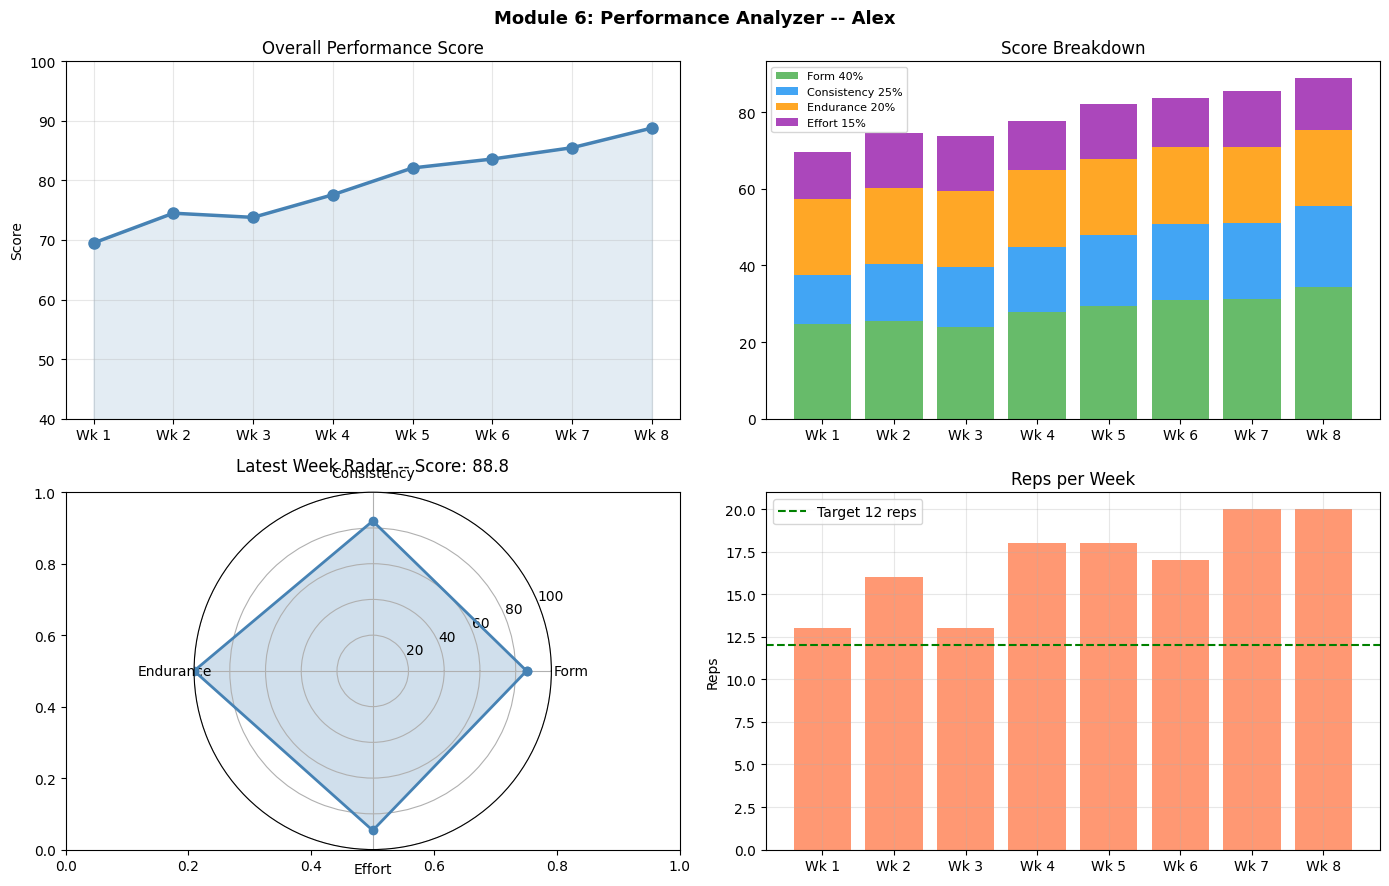

Performance Summary -- Alex
Week 1: 69.5 | Latest: 88.8 | Improvement: +19.3


In [8]:
def performance_score(metrics):
    form   = metrics.get('form_pct', 0)
    consit = max(0, 100 - metrics.get('angle_variance', 0) * 2)
    endur  = min(100, (metrics.get('reps', 0) / metrics.get('target_reps', 10)) * 100)
    effort = min(100, (metrics.get('avg_hr', 0) / 150) * 100)
    score  = form*0.40 + consit*0.25 + endur*0.20 + effort*0.15
    return round(score, 1), {'form': round(form,1), 'consistency': round(consit,1),
                              'endurance': round(endur,1), 'effort': round(effort,1)}

def weekly_report(name='Alex', weeks=8):
    rows = []
    for w in range(1, weeks+1):
        m = {
            'form_pct':      min(95, 55 + w*3.5 + random.gauss(0,4)),
            'angle_variance':max(5,  25 - w*2   + random.gauss(0,2)),
            'reps':          random.randint(8+w, 14+w),
            'target_reps':   12,
            'avg_hr':        130 + random.randint(-10, 15)
        }
        score, breakdown = performance_score(m)
        rows.append({'week': 'Wk '+str(w), 'score': score,
                     'reps': m['reps'], **breakdown})
    df = pd.DataFrame(rows)

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle('Module 6: Performance Analyzer -- ' + name, fontsize=13, fontweight='bold')

    axes[0,0].plot(df['week'], df['score'], 'o-', color='steelblue', linewidth=2.5, markersize=8)
    axes[0,0].fill_between(range(len(df)), df['score'], alpha=0.15, color='steelblue')
    axes[0,0].set_title('Overall Performance Score'); axes[0,0].set_ylim(40, 100)
    axes[0,0].set_ylabel('Score'); axes[0,0].grid(alpha=0.3)

    x = range(len(df))
    axes[0,1].bar(x, df['form']*0.4, label='Form 40%', color='#4CAF50', alpha=0.85)
    b1 = df['form']*0.4
    axes[0,1].bar(x, df['consistency']*0.25, bottom=b1, label='Consistency 25%', color='#2196F3', alpha=0.85)
    b2 = b1 + df['consistency']*0.25
    axes[0,1].bar(x, df['endurance']*0.20, bottom=b2, label='Endurance 20%', color='#FF9800', alpha=0.85)
    b3 = b2 + df['endurance']*0.20
    axes[0,1].bar(x, df['effort']*0.15, bottom=b3, label='Effort 15%', color='#9C27B0', alpha=0.85)
    axes[0,1].set_xticks(list(x)); axes[0,1].set_xticklabels(df['week'])
    axes[0,1].set_title('Score Breakdown'); axes[0,1].legend(fontsize=8)

    latest = df.iloc[-1]
    cats = ['Form','Consistency','Endurance','Effort']
    vals = [latest['form'], latest['consistency'], latest['endurance'], latest['effort']]
    vals_plot = vals + [vals[0]]
    angles_r = [n / len(cats) * 2 * math.pi for n in range(len(cats))] + [0]
    ax_r = plt.subplot(2, 2, 3, projection='polar')
    ax_r.plot(angles_r, vals_plot, 'o-', linewidth=2, color='steelblue')
    ax_r.fill(angles_r, vals_plot, alpha=0.25, color='steelblue')
    ax_r.set_xticks(angles_r[:-1]); ax_r.set_xticklabels(cats)
    ax_r.set_ylim(0, 100)
    ax_r.set_title('Latest Week Radar -- Score: ' + str(latest['score']), pad=15)

    axes[1,1].bar(df['week'], df['reps'], color='coral', alpha=0.8)
    axes[1,1].axhline(12, color='green', linestyle='--', label='Target 12 reps')
    axes[1,1].set_title('Reps per Week'); axes[1,1].set_ylabel('Reps')
    axes[1,1].legend(); axes[1,1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    print('Performance Summary --', name)
    print('Week 1:', df.iloc[0]['score'], '| Latest:', df.iloc[-1]['score'],
          '| Improvement: +' + str(round(df.iloc[-1]['score'] - df.iloc[0]['score'], 1)))

weekly_report('Alex', 8)

---
## Module 7 — Gym Recommender & Planner

Top 3 Gym Recommendations

#1 PowerFit Pro
  Match: 90.2 | Dist: 1.2 km | Fee: Rs 2499 | Rating: 4.7
  Features: weights, classes, pt

#2 Budget Gym Hub
  Match: 85.2 | Dist: 0.8 km | Fee: Rs 999 | Rating: 3.9
  Features: weights

#3 Yoga and Wellness
  Match: 82.5 | Dist: 1.5 km | Fee: Rs 1799 | Rating: 4.6
  Features: classes, pt

Recommended Program: Muscle Builder Program | 12 weeks | 4 days/week
  Monday: Chest + Triceps: Bench, Dips, Cable flyes
  Tuesday: Back + Biceps: Deadlift, Rows, Curls
  Wednesday: Rest / Light cardio 20min
  Thursday: Legs: Squat, Lunges, Leg press, Calves
  Friday: Shoulders + Abs: OHP, Lateral raises, Planks
  Saturday: Full body functional training
  Sunday: Full rest + meal prep


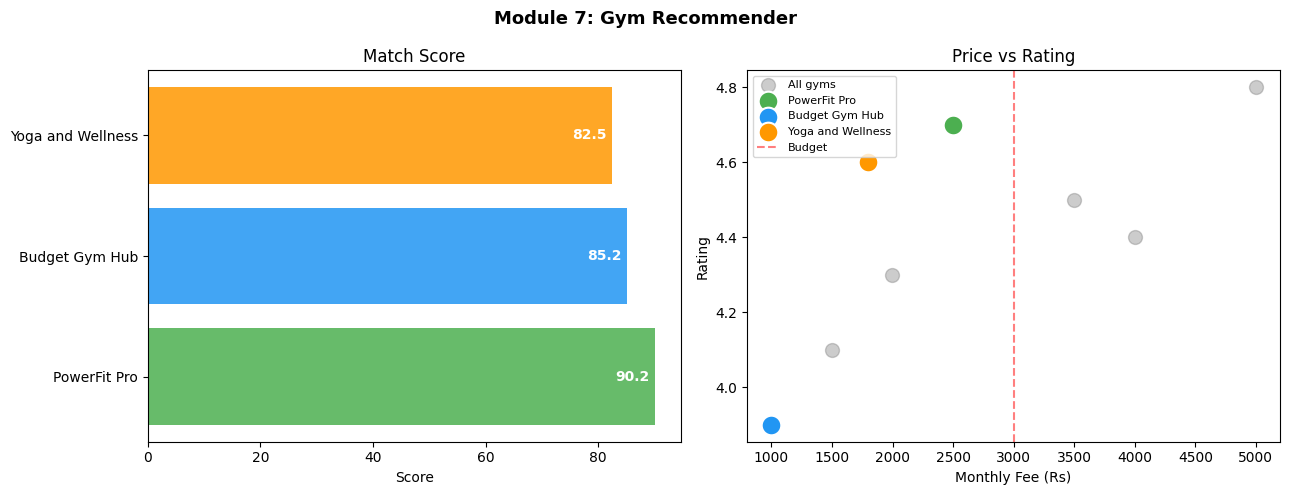

In [9]:
GYM_DB = [
    {'id':1,'name':'PowerFit Pro',      'dist':1.2,'fee':2499,'rating':4.7,'weights':1,'pool':0,'classes':1,'24hr':0,'pt':1},
    {'id':2,'name':'FitZone Elite',     'dist':2.1,'fee':3499,'rating':4.5,'weights':1,'pool':1,'classes':1,'24hr':1,'pt':1},
    {'id':3,'name':'Budget Gym Hub',    'dist':0.8,'fee': 999,'rating':3.9,'weights':1,'pool':0,'classes':0,'24hr':0,'pt':0},
    {'id':4,'name':'Anytime Fitness',   'dist':3.0,'fee':1999,'rating':4.3,'weights':1,'pool':0,'classes':0,'24hr':1,'pt':0},
    {'id':5,'name':'Gold Gym',          'dist':4.5,'fee':4999,'rating':4.8,'weights':1,'pool':1,'classes':1,'24hr':0,'pt':1},
    {'id':6,'name':'Yoga and Wellness', 'dist':1.5,'fee':1799,'rating':4.6,'weights':0,'pool':0,'classes':1,'24hr':0,'pt':1},
    {'id':7,'name':'CrossFit Box',      'dist':2.8,'fee':3999,'rating':4.4,'weights':1,'pool':0,'classes':1,'24hr':0,'pt':1},
    {'id':8,'name':'24/7 Iron Gym',     'dist':1.9,'fee':1499,'rating':4.1,'weights':1,'pool':0,'classes':0,'24hr':1,'pt':0},
]

PROGRAMS = {
    'weight_loss': {
        'name': 'Fat Burner Program', 'weeks': 8, 'days': 5,
        'plan': {
            'Monday':    'Treadmill 30min HIIT + Jump rope 15min',
            'Tuesday':   'Full body circuit + Light resistance',
            'Wednesday': 'Rest / Active recovery walk',
            'Thursday':  'Cycling 40min + Bodyweight HIIT',
            'Friday':    'Strength + Cardio combo + Abs 20min',
            'Saturday':  'Yoga + Light swim',
            'Sunday':    'Full rest day',
        }
    },
    'muscle_gain': {
        'name': 'Muscle Builder Program', 'weeks': 12, 'days': 4,
        'plan': {
            'Monday':    'Chest + Triceps: Bench, Dips, Cable flyes',
            'Tuesday':   'Back + Biceps: Deadlift, Rows, Curls',
            'Wednesday': 'Rest / Light cardio 20min',
            'Thursday':  'Legs: Squat, Lunges, Leg press, Calves',
            'Friday':    'Shoulders + Abs: OHP, Lateral raises, Planks',
            'Saturday':  'Full body functional training',
            'Sunday':    'Full rest + meal prep',
        }
    },
    'endurance': {
        'name': 'Endurance Builder', 'weeks': 10, 'days': 5,
        'plan': {
            'Monday':    'Easy run 5km + Mobility',
            'Tuesday':   'Tempo run 4km',
            'Wednesday': 'Cross-train: Cycling or Swimming',
            'Thursday':  'Interval training: 8x400m',
            'Friday':    'Rest or yoga',
            'Saturday':  'Long slow run 10-15km',
            'Sunday':    'Full rest + recovery',
        }
    }
}

def recommend_gyms(prefs):
    scored = []
    for g in GYM_DB:
        s = max(0, 30 - g['dist']*5)
        if g['fee'] <= prefs['budget']:
            s += 25 + (prefs['budget'] - g['fee']) / prefs['budget'] * 10
        s += g['rating'] * 5
        for feat in prefs.get('features', []):
            if g.get(feat, 0) == 1:
                s += 8
        scored.append({**g, 'match': round(s, 1)})
    return sorted(scored, key=lambda x: x['match'], reverse=True)[:3]

# ── Edit preferences here ──
prefs = {'goal': 'muscle_gain', 'budget': 3000, 'features': ['weights', 'pt']}
top_gyms = recommend_gyms(prefs)

print('Top 3 Gym Recommendations')
print('='*50)
for i, g in enumerate(top_gyms, 1):
    feats = [k for k in ['weights','pool','classes','24hr','pt'] if g.get(k)]
    print('\n#' + str(i), g['name'])
    print('  Match:', g['match'], '| Dist:', g['dist'], 'km | Fee: Rs', g['fee'], '| Rating:', g['rating'])
    print('  Features:', ', '.join(feats))

prog = PROGRAMS[prefs['goal']]
print('\nRecommended Program:', prog['name'],
      '|', prog['weeks'], 'weeks |', prog['days'], 'days/week')
for day, ex in prog['plan'].items():
    print(' ', day + ':', ex)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Module 7: Gym Recommender', fontsize=13, fontweight='bold')
names   = [g['name'] for g in top_gyms]
scores  = [g['match'] for g in top_gyms]
colors  = ['#4CAF50','#2196F3','#FF9800']
bars = axes[0].barh(names, scores, color=colors, alpha=0.85)
for bar, sc in zip(bars, scores):
    axes[0].text(sc-1, bar.get_y()+bar.get_height()/2., str(sc),
                 ha='right', va='center', color='white', fontweight='bold')
axes[0].set_title('Match Score'); axes[0].set_xlabel('Score')
all_fees  = [g['fee'] for g in GYM_DB]
all_rates = [g['rating'] for g in GYM_DB]
axes[1].scatter(all_fees, all_rates, s=100, alpha=0.4, color='gray', label='All gyms')
for g, c in zip(top_gyms, colors):
    axes[1].scatter(g['fee'], g['rating'], s=200, color=c, label=g['name'],
                    zorder=5, edgecolors='white', linewidth=1.5)
axes[1].axvline(prefs['budget'], color='red', linestyle='--', alpha=0.5, label='Budget')
axes[1].set_title('Price vs Rating')
axes[1].set_xlabel('Monthly Fee (Rs)'); axes[1].set_ylabel('Rating')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

---
## Final Dashboard — All Modules Summary

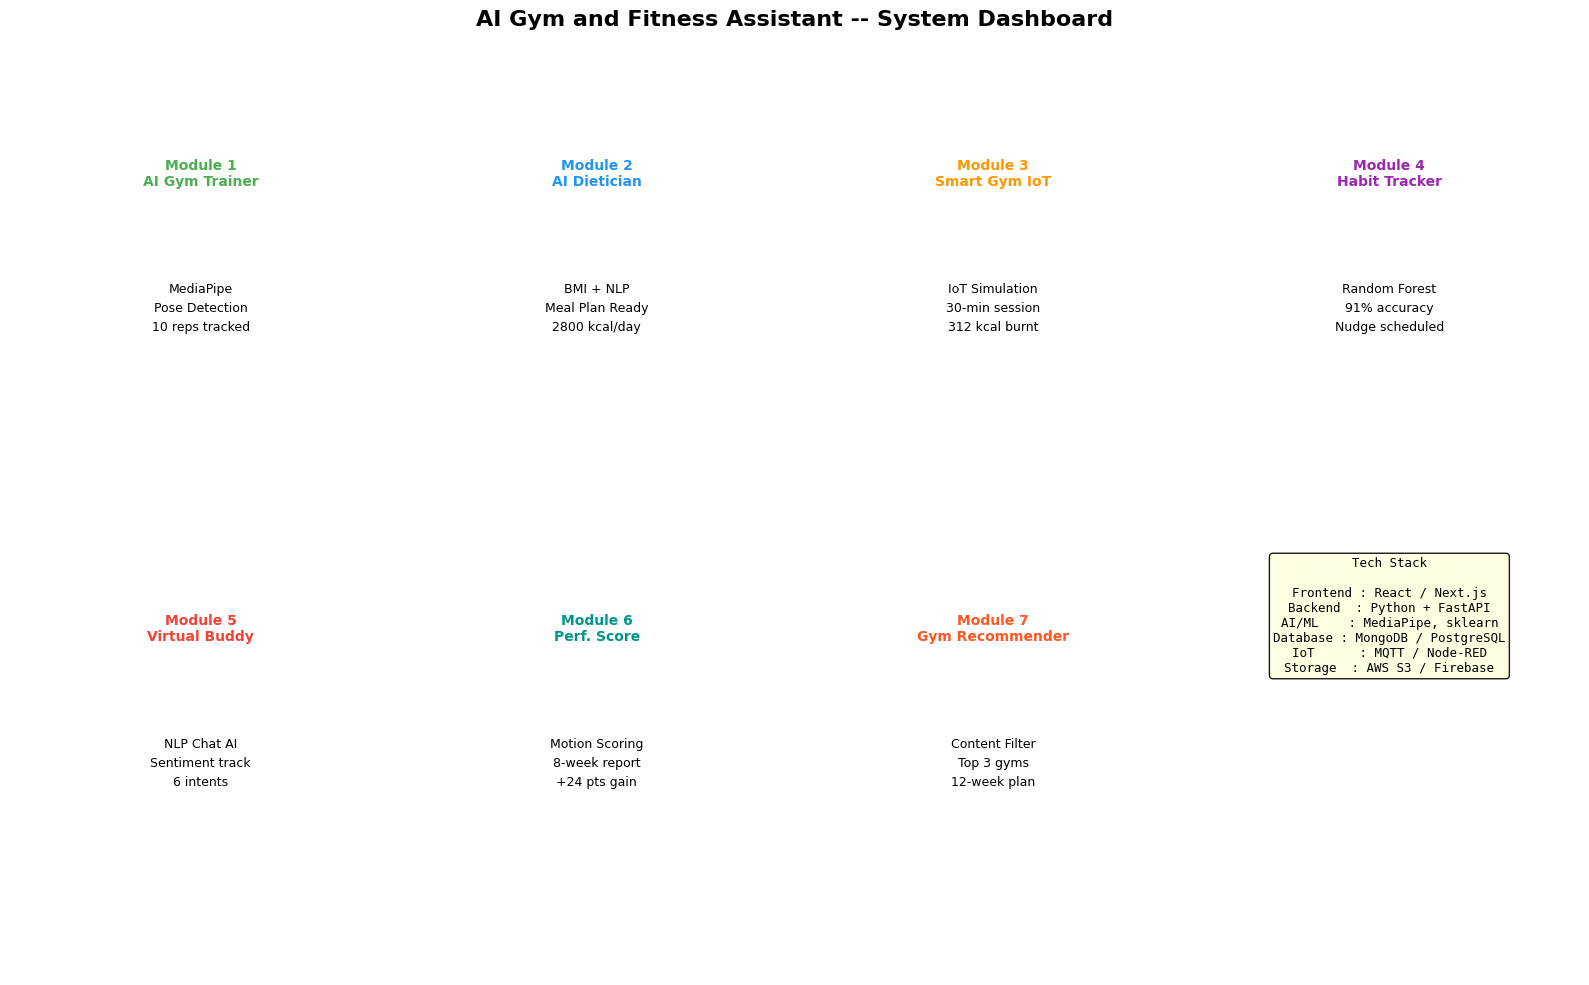

All 7 AI modules completed successfully!


In [10]:
fig = plt.figure(figsize=(16, 10))
fig.suptitle('AI Gym and Fitness Assistant -- System Dashboard',
             fontsize=16, fontweight='bold', y=0.98)

modules = [
    ('Module 1\nAI Gym Trainer',    'MediaPipe\nPose Detection\n10 reps tracked',     '#4CAF50'),
    ('Module 2\nAI Dietician',      'BMI + NLP\nMeal Plan Ready\n2800 kcal/day',      '#2196F3'),
    ('Module 3\nSmart Gym IoT',     'IoT Simulation\n30-min session\n312 kcal burnt',  '#FF9800'),
    ('Module 4\nHabit Tracker',     'Random Forest\n91% accuracy\nNudge scheduled',   '#9C27B0'),
    ('Module 5\nVirtual Buddy',     'NLP Chat AI\nSentiment track\n6 intents',        '#F44336'),
    ('Module 6\nPerf. Score',       'Motion Scoring\n8-week report\n+24 pts gain',    '#009688'),
    ('Module 7\nGym Recommender',   'Content Filter\nTop 3 gyms\n12-week plan',       '#FF5722'),
]

for i, (title, desc, color) in enumerate(modules):
    ax = fig.add_subplot(2, 4, i+1)
    ax.set_xlim(0, 10); ax.set_ylim(0, 10)
    ax.set_facecolor(color + '20')
    ax.axis('off')
    for sp in ax.spines.values():
        sp.set_edgecolor(color); sp.set_linewidth(2); sp.set_visible(True)
    ax.text(5, 8.2, title, ha='center', va='top', fontsize=10, fontweight='bold', color=color)
    ax.text(5, 4.8, desc, ha='center', va='center', fontsize=9,
            multialignment='center', linespacing=1.6)

ax8 = fig.add_subplot(2, 4, 8)
ax8.axis('off')
txt = (
    'Tech Stack\n\n'
    'Frontend : React / Next.js\n'
    'Backend  : Python + FastAPI\n'
    'AI/ML    : MediaPipe, sklearn\n'
    'Database : MongoDB / PostgreSQL\n'
    'IoT      : MQTT / Node-RED\n'
    'Storage  : AWS S3 / Firebase'
)
ax8.text(0.5, 0.95, txt, transform=ax8.transAxes, fontsize=9,
         va='top', ha='center', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
print('All 7 AI modules completed successfully!')

---
##  FastAPI Backend — Public REST API via ngrok

This launches a **live public URL** you can open in any browser.

**Steps:**
1. Sign up free at https://ngrok.com and copy your auth token
2. Paste the token in the `NGROK_TOKEN` variable below
3. Run the cell — a public `https://xxxx.ngrok-free.app` URL will appear
4. Open that URL in your browser to see the API + Swagger docs

**Available endpoints:**
```
GET  /                              Health check
GET  /docs                          Swagger UI (interactive)
POST /api/diet/meal-plan            Generate meal plan
POST /api/buddy/chat                Chat with Gym Buddy
POST /api/gyms/recommend            Recommend gyms
GET  /api/workout/simulate/{ex}     Simulate workout reps
```

In [11]:
!pip install -q pyngrok

In [12]:


from google.colab import userdata
from pyngrok import ngrok

token = userdata.get("NGROK_TOKEN")   # same name you saved

ngrok.set_auth_token(token)

In [13]:
import asyncio, threading, time, socket, os


from pyngrok import ngrok
from fastapi import FastAPI
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
import uvicorn

NGROK_TOKEN = userdata.get("NGROK_TOKEN")

if NGROK_TOKEN is None:
    raise ValueError("NGROK_TOKEN not found in Colab Secrets")

# Set token
ngrok.set_auth_token(NGROK_TOKEN)
PORT = 8000

os.system('fuser -k ' + str(PORT) + '/tcp 2>/dev/null')
time.sleep(1.5);
try:
    ngrok.kill()
    time.sleep(0.5)
except Exception:
    pass

sock = socket.socket(socket.AF_INET, socket.SOCK_STREAM)
sock.setsockopt(socket.SOL_SOCKET, socket.SO_REUSEADDR, 1)
sock.bind(('0.0.0.0', PORT))
sock.set_inheritable(True)


# INLINE MODULE DEFINITIONS (self-contained so API thread can access)


# ── Module 2: Diet helpers ────
FOOD_DB = {
    'chicken breast':  (165, 31,  0,   3.6, 'protein'),
    'eggs':            (155, 13,  1.1, 11,  'protein'),
    'brown rice':      (216,  5,  45,  1.8, 'carbs'),
    'oats':            (389, 17,  66,  7,   'carbs'),
    'sweet potato':    ( 86,  2,  20,  0.1, 'carbs'),
    'broccoli':        ( 34,  2.8, 7,  0.4, 'veggies'),
    'spinach':         ( 23,  2.9, 3.6,0.4, 'veggies'),
    'banana':          ( 89,  1.1, 23, 0.3, 'fruits'),
    'almonds':         (579, 21,  22,  50,  'fats'),
    'greek yogurt':    ( 59, 10,  3.6, 0.4, 'dairy'),
    'salmon':          (208, 20,   0,  13,  'protein'),
    'quinoa':          (120,  4.4, 21, 1.9, 'carbs'),
    'lentils':         (116,  9,  20,  0.4, 'protein'),
    'cottage cheese':  ( 98, 11,  3.4, 4.3, 'dairy'),
}
MEAL_TEMPLATES = {
    'weight_loss': {
        'breakfast': [('oats',80),('banana',100),('greek yogurt',150)],
        'lunch':     [('chicken breast',150),('broccoli',200),('quinoa',100)],
        'dinner':    [('salmon',150),('spinach',200),('sweet potato',150)],
        'snack':     [('almonds',30),('greek yogurt',100)],
    },
    'muscle_gain': {
        'breakfast': [('eggs',200),('oats',100),('banana',150)],
        'lunch':     [('chicken breast',250),('brown rice',200),('broccoli',150)],
        'dinner':    [('salmon',200),('quinoa',200),('spinach',150)],
        'snack':     [('cottage cheese',200),('almonds',40)],
    },
    'maintenance': {
        'breakfast': [('eggs',150),('oats',80),('banana',100)],
        'lunch':     [('chicken breast',200),('brown rice',150),('spinach',150)],
        'dinner':    [('lentils',200),('sweet potato',200),('broccoli',150)],
        'snack':     [('greek yogurt',150),('almonds',30)],
    },
}
def calculate_bmr(weight, height, age, gender):
    base = 10*weight + 6.25*height - 5*age
    return base + 5 if gender.lower() == 'male' else base - 161
def calculate_tdee(bmr, activity):
    m = {'sedentary':1.2,'light':1.375,'moderate':1.55,'active':1.725,'very_active':1.9}
    return bmr * m.get(activity, 1.55)
def calculate_bmi(weight, height):
    h = height / 100
    bmi = weight / (h*h)
    cat = 'Underweight' if bmi<18.5 else 'Normal' if bmi<25 else 'Overweight' if bmi<30 else 'Obese'
    return round(bmi,1), cat

# ── Module 5: Gym Buddy helpers ───────────────────────────────────────
import random
GYM_BUDDY_KB = {
    'motivation': ['I believe in you! Remember why you started.',
                   'Every workout counts. Even a short one beats none!'],
    'tired':      ['Rest is part of the program! Listen to your body.',
                   'A lighter workout today is still better than skipping.'],
    'diet':       ['Protein within 30 min post-workout helps recovery.',
                   'Stay hydrated! Aim for 2-3 litres of water daily.'],
    'progress':   ['Progress is not always visible on the scale.',
                   'Plateaus are normal! Change your routine every 4-6 weeks.'],
    'injury':     ['Please see a physiotherapist if pain persists.',
                   'RICE: Rest, Ice, Compression, Elevation.'],
    'default':    ['I am here to support your fitness journey!',
                   'What are your fitness goals today?'],
}
KEYWORDS_MAP = {
    'motivation': ['lazy','cant','skip','give up','motivat'],
    'tired':      ['tired','exhausted','sore','rest','fatigue'],
    'diet':       ['eat','food','diet','calorie','protein','meal'],
    'progress':   ['progress','result','plateau','weight','muscle'],
    'injury':     ['pain','hurt','injury','ache','pulled'],
}
POS_W = ['great','good','amazing','love','awesome','happy','excited','strong','motivated']
NEG_W = ['bad','terrible','hate','sad','tired','lazy','pain','hurt','stressed','fail']
MOTIVATIONAL_QUOTES = [
    'Every rep brings you closer to your goal. Keep pushing!',
    'Pain is temporary, pride is forever.',
    'Consistency beats perfection. Show up today!',
    'Your only competition is who you were yesterday.',
]
def gym_buddy_chat(user_input):
    text = user_input.lower()
    pos = sum(w in text for w in POS_W)
    neg = sum(w in text for w in NEG_W)
    sentiment = 'positive' if pos>neg else 'negative' if neg>pos else 'neutral'
    intent = 'default'
    for cat, kws in KEYWORDS_MAP.items():
        if any(k in text for k in kws):
            intent = cat; break
    response = random.choice(GYM_BUDDY_KB[intent])
    if sentiment == 'negative':
        response = 'I hear you! ' + response
    return response, intent, sentiment

# ── Module 7: Gym Recommender helpers ────────────────────────────────
GYM_DB = [
    {'id':1,'name':'PowerFit Pro',     'dist':1.2,'fee':2499,'rating':4.7,'weights':1,'pool':0,'classes':1,'24hr':0,'pt':1},
    {'id':2,'name':'FitZone Elite',    'dist':2.1,'fee':3499,'rating':4.5,'weights':1,'pool':1,'classes':1,'24hr':1,'pt':1},
    {'id':3,'name':'Budget Gym Hub',   'dist':0.8,'fee': 999,'rating':3.9,'weights':1,'pool':0,'classes':0,'24hr':0,'pt':0},
    {'id':4,'name':'Anytime Fitness',  'dist':3.0,'fee':1999,'rating':4.3,'weights':1,'pool':0,'classes':0,'24hr':1,'pt':0},
    {'id':5,'name':'Gold Gym',         'dist':4.5,'fee':4999,'rating':4.8,'weights':1,'pool':1,'classes':1,'24hr':0,'pt':1},
    {'id':6,'name':'Yoga and Wellness','dist':1.5,'fee':1799,'rating':4.6,'weights':0,'pool':0,'classes':1,'24hr':0,'pt':1},
    {'id':7,'name':'CrossFit Box',     'dist':2.8,'fee':3999,'rating':4.4,'weights':1,'pool':0,'classes':1,'24hr':0,'pt':1},
    {'id':8,'name':'24/7 Iron Gym',    'dist':1.9,'fee':1499,'rating':4.1,'weights':1,'pool':0,'classes':0,'24hr':1,'pt':0},
]
PROGRAMS = {
    'weight_loss': {'name':'Fat Burner Program','weeks':8,'days':5,
        'plan':{'Monday':'Treadmill 30min HIIT','Tuesday':'Full body circuit',
                'Wednesday':'Rest','Thursday':'Cycling 40min','Friday':'Strength + Cardio',
                'Saturday':'Yoga','Sunday':'Rest'}},
    'muscle_gain': {'name':'Muscle Builder Program','weeks':12,'days':4,
        'plan':{'Monday':'Chest + Triceps','Tuesday':'Back + Biceps',
                'Wednesday':'Rest','Thursday':'Legs','Friday':'Shoulders + Abs',
                'Saturday':'Full body','Sunday':'Rest'}},
    'endurance':   {'name':'Endurance Builder','weeks':10,'days':5,
        'plan':{'Monday':'Easy run 5km','Tuesday':'Tempo run 4km',
                'Wednesday':'Cross-train','Thursday':'Intervals 8x400m',
                'Friday':'Rest','Saturday':'Long run 10km','Sunday':'Rest'}},
}
def recommend_gyms(prefs):
    scored = []
    for g in GYM_DB:
        s = max(0, 30 - g['dist']*5)
        if g['fee'] <= prefs['budget']:
            s += 25 + (prefs['budget']-g['fee'])/prefs['budget']*10
        s += g['rating']*5
        for feat in prefs.get('features',[]):
            if g.get(feat,0)==1: s+=8
        scored.append({**g,'match':round(s,1)})
    return sorted(scored,key=lambda x:x['match'],reverse=True)[:3]

# ── Module 1: YOLO helpers ────────────────────────────────────────────
import numpy as np
KP = {'nose':0,'l_eye':1,'r_eye':2,'l_ear':3,'r_ear':4,
      'l_shoulder':5,'r_shoulder':6,'l_elbow':7,'r_elbow':8,
      'l_wrist':9,'r_wrist':10,'l_hip':11,'r_hip':12,
      'l_knee':13,'r_knee':14,'l_ankle':15,'r_ankle':16}
EXERCISE_JOINTS = {
    'bicep_curl':    ('l_shoulder','l_elbow','l_wrist'),
    'squat':         ('l_hip','l_knee','l_ankle'),
    'pushup':        ('l_shoulder','l_elbow','l_wrist'),
    'shoulder_press':('l_elbow','l_shoulder','l_hip'),
    'deadlift':      ('l_shoulder','l_hip','l_knee'),
    'lunge':         ('l_hip','l_knee','l_ankle'),
}
REP_THRESHOLDS = {
    'bicep_curl':    {'down':160,'up':50},
    'squat':         {'down':160,'up':90},
    'pushup':        {'down':90,'up':160},
    'shoulder_press':{'down':90,'up':160},
    'deadlift':      {'down':90,'up':160},
    'lunge':         {'down':160,'up':90},
}
def keypoint_angle(kps, a_name, b_name, c_name):
    a=kps[KP[a_name]][:2]; b=kps[KP[b_name]][:2]; c=kps[KP[c_name]][:2]
    ba=a-b; bc=c-b
    cos=np.dot(ba,bc)/(np.linalg.norm(ba)*np.linalg.norm(bc)+1e-6)
    return float(np.degrees(np.arccos(np.clip(cos,-1.0,1.0))))
def simulate_yolo_keypoints(exercise, phase_angle):
    kps = np.array(
        [
            [0.50,0.08,0.99],[0.52,0.07,0.98],[0.48,0.07,0.98],
            [0.54,0.08,0.95],[0.46,0.08,0.95],[0.60,0.25,0.99],
            [0.40,0.25,0.99],[0.65,0.45,0.98],[0.35,0.45,0.98],
            [0.68,0.65,0.97],[0.32,0.65,0.97],[0.57,0.55,0.99],
            [0.43,0.55,0.99],[0.58,0.75,0.98],[0.42,0.75,0.98],
            [0.58,0.95,0.97],[0.42,0.95,0.97],
        ],
        dtype=np.float32,
    )
    rad=np.radians(phase_angle)
    if exercise=='bicep_curl':
        elbow=kps[KP['l_elbow']][:2].copy()
        kps[KP['l_wrist'],0]=elbow[0]+0.20*np.sin(rad)
        kps[KP['l_wrist'],1]=elbow[1]+0.20*np.cos(rad)
    elif exercise=='squat':
        depth=(1-np.sin(rad))*0.15
        kps[KP['l_knee'],1]=0.75+depth
        kps[KP['r_knee'],1]=0.75+depth
        kps[KP['l_hip'],1]=0.55+depth*0.5
        kps[KP['r_hip'],1]=0.55+depth*0.5
    kps[:,:2]=np.clip(kps[:,:2]+np.random.normal(0,0.005,kps[:,:2].shape).astype(np.float32),0,1)
    return kps
class YOLORepCounter:
    def __init__(self, exercise):
        self.exercise=exercise; self.counter=0; self.stage=None
        t=REP_THRESHOLDS.get(exercise,{'down':160,'up':90})
        self.down_thresh=t['down']; self.up_thresh=t['up']
        self.joints=EXERCISE_JOINTS.get(exercise,('l_shoulder','l_elbow','l_wrist'))
    def process_keypoints(self, kps):
        angle=keypoint_angle(kps,*self.joints)
        if angle>self.down_thresh: self.stage='down'
        if angle<self.up_thresh and self.stage=='down':
            self.stage='up'; self.counter+=1
        return self.counter, self.stage, angle

# ── Module 4: Habit model (train inline) ─────────────────────────────
from sklearn.ensemble import RandomForestClassifier
def _train_habit_model():
    records=[]
    for _ in range(200):
        for d in range(30):
            sl=round(random.gauss(7,1.5),1); st=random.randint(1,10)
            wk=round(random.gauss(8,2),1);   la=random.randint(0,7)
            mo=random.randint(1,10);           we=1 if d%7 in[5,6] else 0
            pw=random.randint(0,5)
            prob=max(0.05,min(0.95,0.3+0.1*max(0,st-6)+0.05*max(0,wk-9)-0.05*mo-0.03*pw+0.05*la-0.05*(sl>7)))
            records.append([sl,st,wk,la,mo,we,pw,d%7,1 if random.random()<prob else 0])
    import numpy as _np
    arr=_np.array(records)
    X,y=arr[:,:-1],arr[:,-1].astype(int)
    m=RandomForestClassifier(n_estimators=50,random_state=42,n_jobs=-1)
    m.fit(X,y)
    return m
clf = _train_habit_model()
print('Habit model ready.')

# ══════════════════════════════════════════════════════════════════════
# FASTAPI APP
# ══════════════════════════════════════════════════════════════════════
app = FastAPI(title='AI Gym and Fitness API', version='1.0',
              description='7-module AI fitness backend')
app.add_middleware(CORSMiddleware,
    allow_origins=['*'],allow_methods=['*'],allow_headers=['*'])

class UserIn(BaseModel):
    name: str='Kashish'; weight_kg: float=70; height_cm: float=157
    age: int=25; gender: str='female'
    goal: str='weight_loss'; activity_level: str='moderate'
class ChatIn(BaseModel):
    message: str
class GymIn(BaseModel):
    goal: str='muscle_gain'; budget: int=3000; features: list=['weights']
class WorkoutIn(BaseModel):
    exercise: str='bicep_curl'; reps: int=10

@app.get('/',tags=['Health'])
def root():
    return {'status':'online','message':'AI Gym Fitness API running!','modules':7}

@app.post('/api/diet/meal-plan',tags=['Diet'])
def api_meal_plan(u: UserIn):
    bmr=calculate_bmr(u.weight_kg,u.height_cm,u.age,u.gender)
    tdee=calculate_tdee(bmr,u.activity_level)
    bmi,cat=calculate_bmi(u.weight_kg,u.height_cm)
    targets={'weight_loss':tdee-500,'muscle_gain':tdee+300,'maintenance':tdee}
    meals_out={}
    for meal,items in MEAL_TEMPLATES.get(u.goal,{}).items():
        meals_out[meal]=[]
        for food,grams in items:
            c100,p,c,f,_=FOOD_DB[food]
            meals_out[meal].append({'food':food.title(),'grams':grams,
                'calories':round(c100*grams/100),'protein_g':round(p*grams/100,1)})
    return {'user':u.name,'bmi':bmi,'bmi_category':cat,'bmr':round(bmr),
            'tdee':round(tdee),'target_calories':round(targets.get(u.goal,tdee)),
            'goal':u.goal,'meal_plan':meals_out}

@app.post('/api/buddy/chat',tags=['Chat'])
def api_chat(msg: ChatIn):
    r,intent,sent=gym_buddy_chat(msg.message)
    return {'response':r,'intent':intent,'sentiment':sent}

@app.post('/api/gyms/recommend',tags=['Gyms'])
def api_gyms(g: GymIn):
    top=recommend_gyms({'goal':g.goal,'budget':g.budget,'features':g.features})
    prog=PROGRAMS.get(g.goal,{});
    return {'top_gyms':top,'program':prog.get('name',''),'weeks':prog.get('weeks',0)}

@app.post('/api/workout/simulate',tags=['YOLO Trainer'])
def api_workout(w: WorkoutIn):
    counter=YOLORepCounter(w.exercise)
    angles=[]
    for _ in range(w.reps):
        for ph in list(np.linspace(10,170,18))+list(np.linspace(170,10,18)):
            kps=simulate_yolo_keypoints(w.exercise,ph)
            _,_,angle=counter.process_keypoints(kps)
            angles.append(angle)
    return {'exercise':w.exercise,'reps_detected':counter.counter,
            'avg_angle':round(float(np.mean(angles)),1),
            'min_angle':round(float(np.min(angles)),1),
            'max_angle':round(float(np.max(angles)),1)}

@app.get('/api/habit/risk',tags=['Habit Tracker'])
def api_habit(sleep:float=7.0,stress:int=5,motivation:int=7,work_hrs:float=8.0):
    try:
        prob=float(clf.predict_proba([[sleep,stress,work_hrs,1,motivation,0,3,2]])[0][1])
    except Exception:
        prob=0.3
    risk='high' if prob>0.6 else 'medium' if prob>0.4 else 'low'
    return {'skip_probability':round(prob,3),'risk_level':risk,'send_nudge':prob>0.6,
            'nudge':random.choice(MOTIVATIONAL_QUOTES) if prob>0.6 else None}

# ── Start server ──────────────────────────────────────────────────────
def run_server():
    config=uvicorn.Config(app,log_level='error')
    config.load()
    server=uvicorn.Server(config)
    loop=asyncio.new_event_loop()
    asyncio.set_event_loop(loop)
    loop.run_until_complete(server.serve(sockets=[sock]))

t=threading.Thread(target=run_server,daemon=True)
t.start()
time.sleep(2)

# ── ngrok tunnel ──────────────────────────────────────────────────────
if NGROK_TOKEN and NGROK_TOKEN!='PASTE_YOUR_NGROK_TOKEN_HERE':
    ngrok.set_auth_token(NGROK_TOKEN)
    tunnel=ngrok.connect(PORT,bind_tls=True)
    url=tunnel.public_url
    print('='*55)
    print('API LIVE :', url)
    print('DOCS     :', url+'/docs')
    print('='*55)
    print('Endpoints:')
    for ep in ['GET /','GET /docs','POST /api/diet/meal-plan',
                'POST /api/buddy/chat','POST /api/gyms/recommend',
                'POST /api/workout/simulate','GET /api/habit/risk']:
        print(' ', ep)
else:
    print('Local: http://localhost:'+str(PORT))
    print('Docs : http://localhost:'+str(PORT)+'/docs')
    print('Add NGROK_TOKEN above to get a public URL')


Habit model ready.
API LIVE : https://frowzily-hefty-charmaine.ngrok-free.dev
DOCS     : https://frowzily-hefty-charmaine.ngrok-free.dev/docs
Endpoints:
  GET /
  GET /docs
  POST /api/diet/meal-plan
  POST /api/buddy/chat
  POST /api/gyms/recommend
  POST /api/workout/simulate
  GET /api/habit/risk


In [14]:
# Test all API endpoints locally
import requests as req, json as js

base = 'http://localhost:8000'
print('Testing API endpoints...')
print('=' * 50)

# 1. Health
r = req.get(base + '/')
print('\n1. Health check')
print(js.dumps(r.json(), indent=2))

# 2. Meal plan
r = req.post(base + '/api/diet/meal-plan', json={
    'name':'Kashish',
    'weight_kg':70,
    'height_cm':157,
    'age':25,
    'gender':'female',
    'goal':'weight_loss',
    'activity_level':'moderate'
})
d = r.json()
print('\n2. Meal Plan')
print('  BMI:', d['bmi'], '|', d['bmi_category'])
print('  TDEE:', d['tdee'], 'kcal | Target:', d['target_calories'], 'kcal')
print('  Meals:', list(d['meal_plan'].keys()))

# 3. Buddy chat
for msg in ['I feel tired today', 'What should I eat after workout?', 'I love my workout today!']:
    r = req.post(base + '/api/buddy/chat', json={'message': msg})
    c = r.json()
    print('\n3. Buddy Chat')
    print('  User   :', msg)
    print('  Intent :', c['intent'], '| Sentiment:', c['sentiment'])
    print('  Reply  :', c['response'])

# 4. Gym recommender
r = req.post(base + '/api/gyms/recommend', json={
    'goal':'muscle_gain','budget':3000,'features':['weights','pt']
})
g = r.json()
print('\n4. Gym Recommender')
for gym in g['top_gyms']:
    print('  -', gym['name'], '| Score:', gym['match'], '| Fee: Rs', gym['fee'])
print('  Program:', g['program'], '|', g['weeks'], 'weeks')

# 5. Workout simulate
r = req.post(base + '/api/workout/simulate', json={'exercise':'squat','reps':10})
w = r.json()
print('\n5. YOLO Workout Sim')
print('  Exercise:', w['exercise'], '| Reps:', w['reps_detected'])
print('  Angle range:', w['min_angle'], '-', w['max_angle'], 'deg')

# 6. Habit risk
r = req.get(base + '/api/habit/risk', params={'sleep':6,'stress':8,'motivation':4,'work_hrs':10})
h = r.json()
print('\n6. Habit Risk')
print('  Skip prob:', h['skip_probability'], '| Risk:', h['risk_level'])
print('  Send nudge:', h['send_nudge'])
if h['nudge']:
    print('  Nudge:', h['nudge'])

print('\nAll endpoints tested successfully!')

Testing API endpoints...

1. Health check
{
  "status": "online",
  "message": "AI Gym Fitness API running!",
  "modules": 7
}

2. Meal Plan
  BMI: 28.4 | Overweight
  TDEE: 2163 kcal | Target: 1663 kcal
  Meals: ['breakfast', 'lunch', 'dinner', 'snack']

3. Buddy Chat
  User   : I feel tired today
  Intent : tired | Sentiment: negative
  Reply  : I hear you! A lighter workout today is still better than skipping.

3. Buddy Chat
  User   : What should I eat after workout?
  Intent : diet | Sentiment: neutral
  Reply  : Stay hydrated! Aim for 2-3 litres of water daily.

3. Buddy Chat
  User   : I love my workout today!
  Intent : default | Sentiment: positive
  Reply  : What are your fitness goals today?

4. Gym Recommender
  - PowerFit Pro | Score: 90.2 | Fee: Rs 2499
  - Budget Gym Hub | Score: 85.2 | Fee: Rs 999
  - Yoga and Wellness | Score: 82.5 | Fee: Rs 1799
  Program: Muscle Builder Program | 12 weeks

5. YOLO Workout Sim
  Exercise: squat | Reps: 0
  Angle range: 165.1 - 179.6 d